Лаб №2.

Пункт 1.

In [20]:
import numpy as np
import pandas as pd
import seaborn as sns
sns.set_palette('husl')
import matplotlib.pyplot as plt
%matplotlib inline
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import classification_report
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn import metrics
import warnings
warnings.filterwarnings('ignore')
from sklearn.preprocessing import LabelEncoder

Пункт 2.

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Пункт 3.

In [3]:
df = pd.read_csv('/content/drive/MyDrive/paddydataset.csv')
print(f"Размер датасета: {df.shape}")
print(f"\nПервые 5 строк:")
print(df.head())
print(f"\nИнформация о датасете:")
df.info()

Размер датасета: (2789, 45)

Первые 5 строк:
   Hectares      Agriblock      Variety Soil Types  Seedrate(in Kg)  \
0          6     Cuddalore        CO_43   alluvial              150   
1          6   Kurinjipadi      ponmani       clay              150   
2          6       Panruti  delux ponni   alluvial              150   
3          6  Kallakurichi        CO_43       clay              150   
4          6  Sankarapuram      ponmani   alluvial              150   

   LP_Mainfield(in Tonnes) Nursery  Nursery area (Cents)  \
0                     75.0     dry                   120   
1                     75.0     wet                   120   
2                     75.0     dry                   120   
3                     75.0     wet                   120   
4                     75.0     dry                   120   

   LP_nurseryarea(in Tonnes)  DAP_20days  ...  Wind Direction_D1_D30  \
0                          6         240  ...                     SW   
1                      

Пункт 4.

In [7]:
print("\nСтатистическое описание числовых признаков:")
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
if 'ID' in numeric_cols:
    numeric_cols.remove('ID')
print(df[numeric_cols].describe())

# Создаем классы на основе квантилей урожайности
df['class'] = pd.qcut(df['Paddy yield(in Kg)'],
                       q=3,  # 3 класса
                       labels=['Low', 'Medium', 'High'])

print("Распределение классов:")
print(df['class'].value_counts())
print("\nСтатистика по классам:")
print(df.groupby('class')['Paddy yield(in Kg)'].agg(['min', 'max', 'mean', 'count']))


Статистическое описание числовых признаков:
         Hectares   Seedrate(in Kg)  LP_Mainfield(in Tonnes)  \
count  2789.000000      2789.000000              2789.000000   
mean      3.717461        92.936536                46.468268   
std       1.437777        35.944420                17.972210   
min       1.000000        25.000000                12.500000   
25%       3.000000        75.000000                37.500000   
50%       4.000000       100.000000                50.000000   
75%       5.000000       125.000000                62.500000   
max       6.000000       150.000000                75.000000   

       Nursery area (Cents)  LP_nurseryarea(in Tonnes)   DAP_20days  \
count           2789.000000                2789.000000  2789.000000   
mean              74.349229                   3.717461   148.698458   
std               28.755536                   1.437777    57.511072   
min               20.000000                   1.000000    40.000000   
25%               60.00

Пункт 5. Визуализация данных.

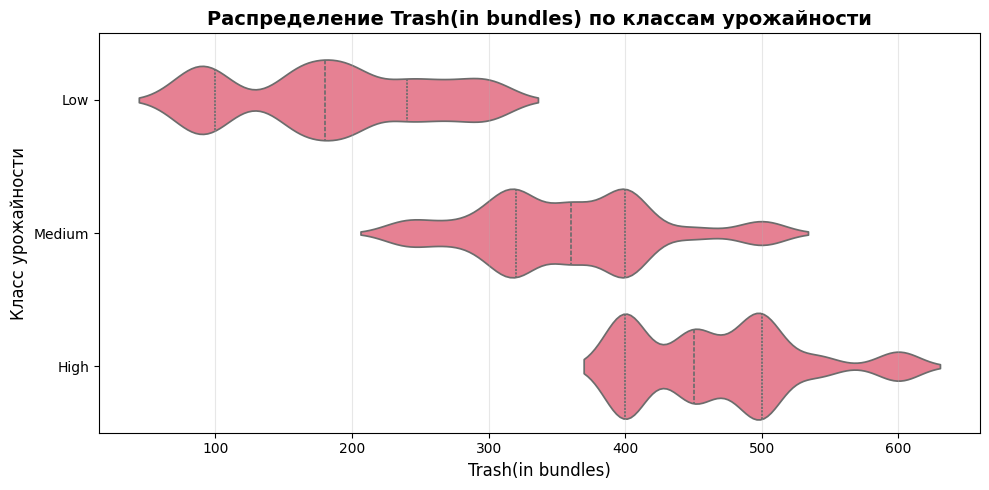

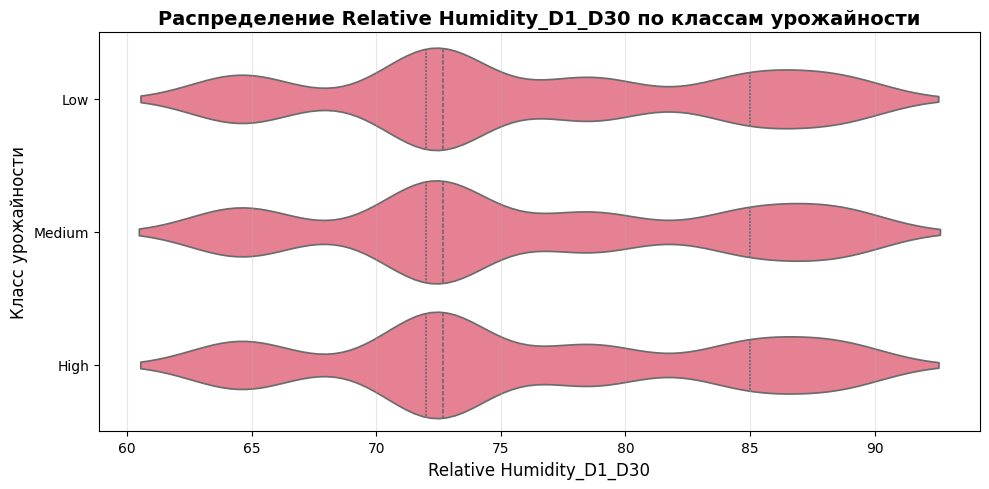

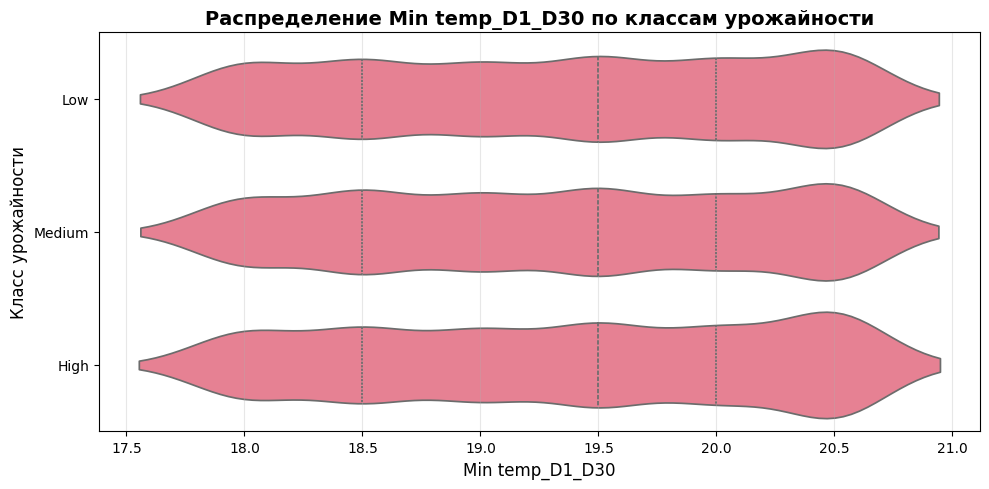

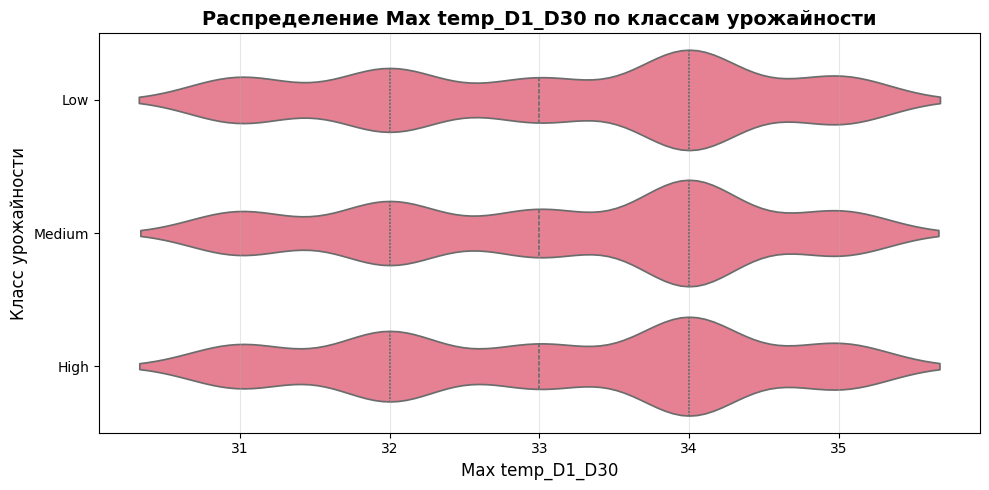

In [13]:
features_to_plot = [
    'Trash(in bundles)',    # солома
    'Relative Humidity_D1_D30',  # влажность первые 30 дней
    'Min temp_D1_D30',      # мин температура первые 30 дней
    'Max temp_D1_D30'       # макс температура первые 30 дней
]

for feature in features_to_plot:
    if feature in df.columns:
        plt.figure(figsize=(10, 5))
        sns.violinplot(y='class', x=feature, data=df, inner='quartile')
        plt.title(f'Распределение {feature} по классам урожайности', fontsize=14, fontweight='bold')
        plt.xlabel(feature, fontsize=12)
        plt.ylabel('Класс урожайности', fontsize=12)
        plt.grid(axis='x', alpha=0.3)
        plt.tight_layout()
        plt.show()

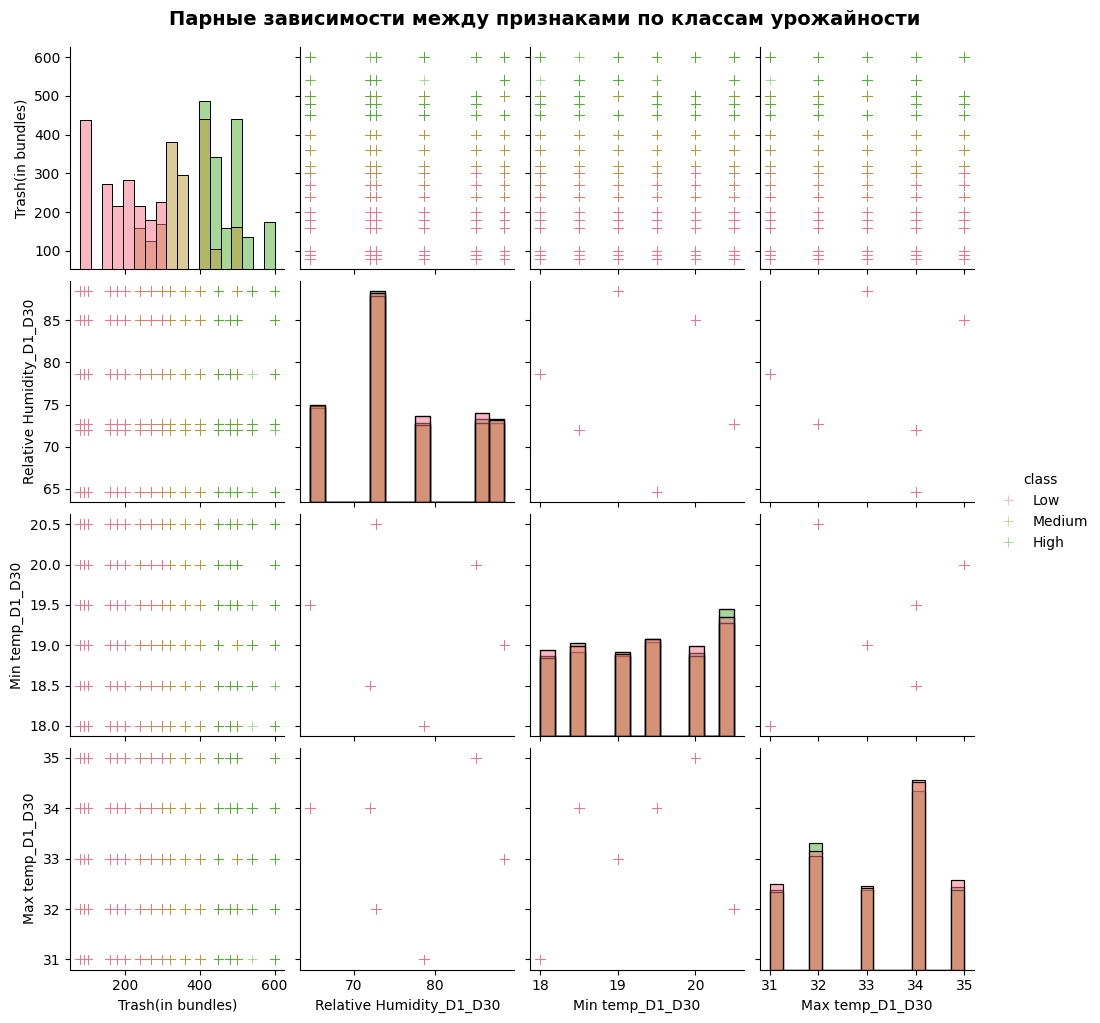

In [16]:
selected_features = [
    'Trash(in bundles)',
    'Relative Humidity_D1_D30',
    'Min temp_D1_D30',
    'Max temp_D1_D30'
]
sns.pairplot(df,
             hue='class',
             vars=selected_features,
             markers='+',
             plot_kws={'alpha': 0.6, 's': 50},
             diag_kind='hist')
plt.suptitle('Парные зависимости между признаками по классам урожайности', y=1.02, fontsize=14, fontweight='bold')
plt.show()

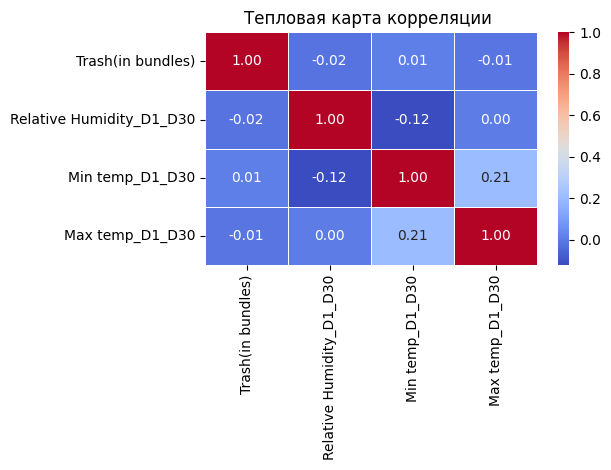

In [17]:
selected_features = [
    'Trash(in bundles)',
    'Relative Humidity_D1_D30',
    'Min temp_D1_D30',
    'Max temp_D1_D30'
]
corr_matrix = df[selected_features].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', linewidths=0.5, fmt='.2f')
plt.title('Тепловая карта корреляции ')
plt.tight_layout()
plt.show()

Пункт 6. Построение модели.

In [22]:
numeric_columns = df.select_dtypes(include=[np.number]).columns.tolist()
numeric_columns.remove('Paddy yield(in Kg)')
X = df[numeric_columns]
y = df['class']
print(f"Используемые числовые признаки: {X.columns.tolist()}")
print(f"\nX shape: {X.shape} | y shape: {y.shape}")
le = LabelEncoder()
y_encoded = le.fit_transform(y)
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded,
    test_size=0.20,
    random_state=10,
    stratify=y_encoded
)
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")

Используемые числовые признаки: ['Hectares ', 'Seedrate(in Kg)', 'LP_Mainfield(in Tonnes)', 'Nursery area (Cents)', 'LP_nurseryarea(in Tonnes)', 'DAP_20days', 'Weed28D_thiobencarb', 'Urea_40Days', 'Potassh_50Days', 'Micronutrients_70Days', 'Pest_60Day(in ml)', '30DRain( in mm)', '30DAI(in mm)', '30_50DRain( in mm)', '30_50DAI(in mm)', '51_70DRain(in mm)', '51_70AI(in mm)', '71_105DRain(in mm)', '71_105DAI(in mm)', 'Min temp_D1_D30', 'Max temp_D1_D30', 'Min temp_D31_D60', 'Max temp_D31_D60', 'Min temp_D61_D90', 'Max temp_D61_D90', 'Min temp_D91_D120', 'Max temp_D91_D120', 'Inst Wind Speed_D1_D30(in Knots)', 'Inst Wind Speed_D31_D60(in Knots)', 'Inst Wind Speed_D61_D90(in Knots)', 'Inst Wind Speed_D91_D120(in Knots)', 'Relative Humidity_D1_D30', 'Relative Humidity_D31_D60', 'Relative Humidity_D61_D90', 'Relative Humidity_D91_D120', 'Trash(in bundles)']

X shape: (2789, 36) | y shape: (2789,)
X_train shape: (2231, 36)
X_test shape: (558, 36)


In [23]:
models = []
models.append(('LR', LogisticRegression(solver='lbfgs', max_iter=1000)))
models.append(('LDA', LinearDiscriminantAnalysis()))
models.append(('KNN', KNeighborsClassifier()))
models.append(('CART', DecisionTreeClassifier()))
models.append(('NB', GaussianNB()))
models.append(('SVC', SVC(gamma='auto')))
results = []
model_names = []
print("\nРезультаты кросс-валидации моделей:")
for name, model in models:
    kfold = StratifiedKFold(n_splits=5, random_state=1, shuffle=True)
    cv_results = cross_val_score(model, X_train, y_train, cv=kfold, scoring='accuracy')
    results.append(cv_results)
    model_names.append(name)
    print('%s: %f (%f)' % (name, cv_results.mean(), cv_results.std()))


Результаты кросс-валидации моделей:
LR: 0.888392 (0.006840)
LDA: 0.852084 (0.023856)
KNN: 0.870914 (0.015273)
CART: 0.880773 (0.004526)
NB: 0.886150 (0.002608)
SVC: 0.880325 (0.004969)


In [24]:
nb_model = GaussianNB()
nb_model.fit(X_train, y_train)
nb_pred_res = nb_model.predict(X_test)
nb_probabilities = nb_model.predict_proba(X_train)
nb_accuracy = accuracy_score(y_test, nb_pred_res)
print('РЕЗУЛЬТАТЫ МОДЕЛИ NAIVE BAYES (NB)')
print(f'NB accuracy: {nb_accuracy:.4f}')
print(f'\nNB prediction (первые 30 элементов):')
print(nb_pred_res)
print('\nNB class probabilities for first 5 training samples:')
print('(вероятности для классов)')
print(nb_probabilities[:4].T)

РЕЗУЛЬТАТЫ МОДЕЛИ NAIVE BAYES (NB)
NB accuracy: 0.8781

NB prediction (первые 30 элементов):
[0 1 1 0 2 0 2 1 0 0 0 0 2 1 1 1 0 1 1 1 2 0 2 2 0 0 1 1 1 2 0 1 0 2 2 0 0
 2 1 0 0 1 0 0 2 0 0 2 2 2 2 0 1 0 0 2 2 1 2 0 0 0 1 0 1 0 0 1 0 0 1 1 0 1
 0 1 2 0 2 1 1 1 1 2 1 1 2 2 1 0 0 2 2 1 2 1 1 1 2 0 0 0 0 0 2 0 1 1 1 1 2
 1 1 0 2 1 0 1 0 0 0 2 2 0 1 1 1 0 1 0 2 0 0 1 1 2 2 1 2 1 1 1 0 1 0 0 1 1
 1 2 2 1 1 1 0 0 0 1 0 1 0 1 1 1 0 0 2 0 0 0 2 2 1 1 0 0 1 1 0 0 0 1 2 2 1
 1 2 1 1 1 1 0 2 1 0 2 1 1 1 0 1 0 0 1 1 1 2 1 0 0 0 1 1 0 0 0 1 2 0 1 2 1
 2 2 2 1 1 0 1 2 2 2 2 0 1 1 2 1 0 0 1 2 2 0 1 2 0 0 0 0 1 2 0 0 1 1 0 0 1
 1 0 1 0 1 0 0 1 0 1 1 1 1 1 1 0 2 1 0 1 1 1 1 1 1 0 1 1 1 1 0 1 1 1 0 2 1
 0 1 0 1 0 1 2 2 1 0 0 1 1 1 1 0 1 0 1 2 0 0 1 0 0 0 2 2 2 1 0 2 0 0 0 0 2
 0 2 1 1 2 0 1 1 2 1 2 1 0 0 2 1 0 0 0 0 1 1 0 1 0 2 2 1 2 1 1 1 0 0 0 2 0
 0 0 1 0 1 2 1 2 1 1 2 1 0 1 0 1 0 2 2 1 2 0 1 0 0 2 0 0 1 1 0 0 2 1 1 1 1
 1 1 0 1 1 0 1 0 0 1 0 0 0 1 0 1 2 1 0 1 1 1 0 0 1 2 1 2 1 0 1 2 1 1 1 0 0
 1 0 0 

Text(0, 0.5, 'Seedrate(in Kg)')

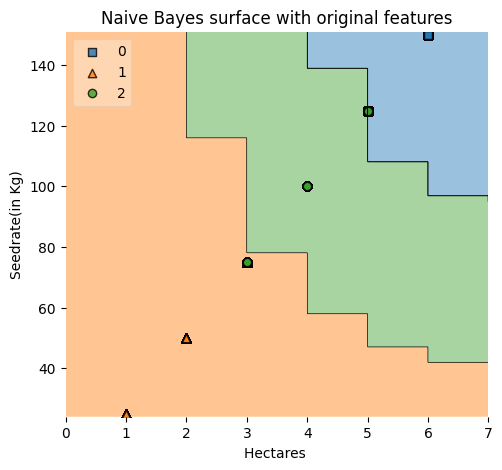

In [25]:
from mlxtend.plotting import plot_decision_regions
feature1 = 'Hectares '
feature2 = 'Seedrate(in Kg)'
X_2d_nb = X_train[[feature1, feature2]].values
y_2d_nb = y_train
nb_model_2d = GaussianNB()
nb_model_2d.fit(X_2d_nb, y_2d_nb)
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plot_decision_regions(
    X=X_2d_nb,
    y=y_2d_nb,
    clf=nb_model_2d,
    legend=2
)
plt.title('Naive Bayes surface with original features')
plt.xlabel(feature1)
plt.ylabel(feature2)

X_all shape: (2789, 36)
Признаки для t-SNE: ['Hectares ', 'Seedrate(in Kg)', 'LP_Mainfield(in Tonnes)', 'Nursery area (Cents)']...
X_tsne shape: (2789, 2)


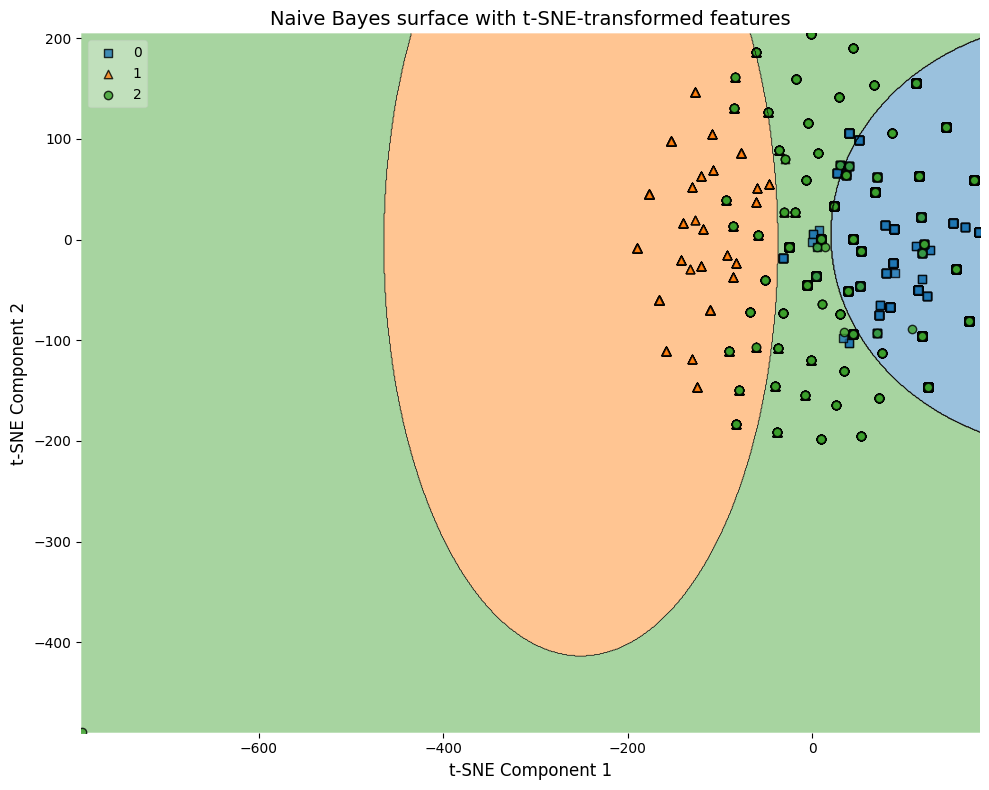

NB + t-SNE accuracy: 0.7867


In [30]:
le = LabelEncoder()
y_encoded = le.fit_transform(y)

print(f"X_all shape: {X_all.shape}")
print(f"Признаки для t-SNE: {X_all.columns.tolist()[:4]}...")

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_all)

tsne = TSNE(n_components=2, random_state=42, perplexity=30)
X_tsne = tsne.fit_transform(X_scaled)

print(f"X_tsne shape: {X_tsne.shape}")
X_tsne_train, X_tsne_test, y_tsne_train, y_tsne_test = train_test_split(
    X_tsne, y_encoded, test_size=0.20, random_state=0, stratify=y_encoded
)

nb_tsne_model = GaussianNB()
nb_tsne_model.fit(X_tsne_train, y_tsne_train)

plt.figure(figsize=(10, 8))
plt.title('Naive Bayes surface with t-SNE-transformed features', fontsize=14)
plot_decision_regions(
    X=X_tsne,
    y=y_encoded,
    clf=nb_tsne_model,
    legend=2
)
plt.xlabel('t-SNE Component 1', fontsize=12)
plt.ylabel('t-SNE Component 2', fontsize=12)
plt.tight_layout()
plt.show()

y_pred_tsne = nb_tsne_model.predict(X_tsne_test)
accuracy_tsne = accuracy_score(y_tsne_test, y_pred_tsne)
print(f"NB + t-SNE accuracy: {accuracy_tsne:.4f}")

In [31]:
predicted_nb = nb_model.predict(X_test)
print("Предсказания NB модели:")
print(predicted_nb)

Предсказания NB модели:
[0 1 1 0 2 0 2 1 0 0 0 0 2 1 1 1 0 1 1 1 2 0 2 2 0 0 1 1 1 2 0 1 0 2 2 0 0
 2 1 0 0 1 0 0 2 0 0 2 2 2 2 0 1 0 0 2 2 1 2 0 0 0 1 0 1 0 0 1 0 0 1 1 0 1
 0 1 2 0 2 1 1 1 1 2 1 1 2 2 1 0 0 2 2 1 2 1 1 1 2 0 0 0 0 0 2 0 1 1 1 1 2
 1 1 0 2 1 0 1 0 0 0 2 2 0 1 1 1 0 1 0 2 0 0 1 1 2 2 1 2 1 1 1 0 1 0 0 1 1
 1 2 2 1 1 1 0 0 0 1 0 1 0 1 1 1 0 0 2 0 0 0 2 2 1 1 0 0 1 1 0 0 0 1 2 2 1
 1 2 1 1 1 1 0 2 1 0 2 1 1 1 0 1 0 0 1 1 1 2 1 0 0 0 1 1 0 0 0 1 2 0 1 2 1
 2 2 2 1 1 0 1 2 2 2 2 0 1 1 2 1 0 0 1 2 2 0 1 2 0 0 0 0 1 2 0 0 1 1 0 0 1
 1 0 1 0 1 0 0 1 0 1 1 1 1 1 1 0 2 1 0 1 1 1 1 1 1 0 1 1 1 1 0 1 1 1 0 2 1
 0 1 0 1 0 1 2 2 1 0 0 1 1 1 1 0 1 0 1 2 0 0 1 0 0 0 2 2 2 1 0 2 0 0 0 0 2
 0 2 1 1 2 0 1 1 2 1 2 1 0 0 2 1 0 0 0 0 1 1 0 1 0 2 2 1 2 1 1 1 0 0 0 2 0
 0 0 1 0 1 2 1 2 1 1 2 1 0 1 0 1 0 2 2 1 2 0 1 0 0 2 0 0 1 1 0 0 2 1 1 1 1
 1 1 0 1 1 0 1 0 0 1 0 0 0 1 0 1 2 1 0 1 1 1 0 0 1 2 1 2 1 0 1 2 1 1 1 0 0
 1 0 0 2 0 1 1 0 0 1 0 2 0 0 1 2 2 0 1 0 1 1 0 1 1 2 2 1 0 0 2 2 0 0 2 1 1
 

In [34]:
from sklearn import metrics
import numpy as np
accuracy_nb = metrics.accuracy_score(y_test, predicted_nb)
recall_nb = metrics.recall_score(y_test, predicted_nb, average="weighted")
precision_nb = metrics.precision_score(y_test, predicted_nb, average="weighted")
f1_nb = metrics.f1_score(y_test, predicted_nb, average="weighted")
print("МЕТРИКИ ДЛЯ NAIVE BAYES (NB)")
print(f"Accuracy: {accuracy_nb:.4f}")
print(f"Recall (weighted): {recall_nb:.4f}")
print(f"Precision (weighted): {precision_nb:.4f}")
print(f"F1-score (weighted): {f1_nb:.4f}")
print("\nДетальный отчет по классификации:")
target_names = ['Low', 'Medium', 'High']
print(metrics.classification_report(y_test, predicted_nb, target_names=target_names))
print("\nДополнительные метрики:")
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, predicted_nb)
print("Confusion Matrix:")
print(cm)
if len(np.unique(y_test)) == 2:
    from sklearn.metrics import roc_auc_score, roc_curve
    y_pred_proba = nb_model.predict_proba(X_test)[:, 1]
    roc_auc = roc_auc_score(y_test, y_pred_proba)
    print(f"ROC AUC: {roc_auc:.4f}")
    from sklearn.metrics import matthews_corrcoef
    mcc = matthews_corrcoef(y_test, predicted_nb)
    print(f"Matthews Correlation Coefficient: {mcc:.4f}")

МЕТРИКИ ДЛЯ NAIVE BAYES (NB)
Accuracy: 0.8781
Recall (weighted): 0.8781
Precision (weighted): 0.8971
F1-score (weighted): 0.8694

Детальный отчет по классификации:
              precision    recall  f1-score   support

         Low       0.86      1.00      0.93       185
      Medium       0.83      1.00      0.91       190
        High       1.00      0.63      0.77       183

    accuracy                           0.88       558
   macro avg       0.90      0.88      0.87       558
weighted avg       0.90      0.88      0.87       558


Дополнительные метрики:
Confusion Matrix:
[[185   0   0]
 [  0 190   0]
 [ 29  39 115]]
